# Copernicus Sea Surface Temperature (SST) Multi-Sensor L3 Observation Converter

This notebook inspects the `obs_seq` file created by the DART CMEMS SST converter.  
The converter itself should be run from the terminal. This notebook focuses on reading, summarizing, and visualizing the output observations.

## Objectives

In this notebook you will learn how to:

- Read a DART `obs_seq` file using pyDARTdiags
- Inspect observation types and metadata
- Visualize observations on a map
- Compute basic observation statistics

## 1. Import Python libraries

In [2]:
import pydartdiags.obs_sequence.obs_sequence as obsq

import os
import cmocean
import numpy             as np
import pandas            as pd
import cartopy.crs       as ccrs
import cartopy.feature   as cfeature
import matplotlib.pyplot as plt
import matplotlib.dates  as mdates

from pathlib              import Path
from IPython.display      import Markdown, display
from pydartdiags.stats    import stats
from pydartdiags.matplots import matplots as mp

/glade/work/gharamti/conda-envs/roms_dart_training/lib/python3.11/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


## 2. Define paths

In [3]:
# Path to DART repo (directory) 
basedir = Path(f"/glade/derecho/scratch/{os.environ['USER']}/inacawo/DART_training")

# Path to the SST converter
sst_dir = basedir / 'observations' / 'obs_converters' / 'cmems_sst_l3s' 

# Path to the obs_seq file
obs_seq_file = sst_dir / 'work' / 'obs_seq.sst'
print(f"obs_seq file: {obs_seq_file}")

# Make sure the obs_Seq file exists
assert obs_seq_file.exists(), 'obs_seq file not found'

obs_seq file: /glade/derecho/scratch/gharamti/inacawo/DART_training/observations/obs_converters/cmems_sst_l3s/work/obs_seq.sst


## 3. Read and preview the obs_seq file

In [4]:
# Read the obs seq file into a DataFrame
obs = obsq.ObsSequence(obs_seq_file)

print(f"DataFrame shape: {obs.df.shape}")
print('\n')

display(obs.df.sample(10))

DataFrame shape: (36638, 15)




,obs_num,observation,QC,linked_list,longitude,latitude,vertical,vert_unit,type,metadata,external_FO,seconds,days,time,obs_err_var
5000,5001,27.790002,0.0,5000 5002 -1,141.250000,-12.749999,0.0,surface (m),SATELLITE_BLENDED_SST,[],[],0,155141,2025-10-06,0.041616
30193,30194,29.570001,0.0,30193 30195 -1,108.650002,6.950000,0.0,surface (m),SATELLITE_BLENDED_SST,[],[],0,155141,2025-10-06,0.042849
2218,2219,26.779993,0.0,2218 2220 -1,116.250000,-13.950000,0.0,surface (m),SATELLITE_BLENDED_SST,[],[],0,155141,2025-10-06,0.015376
8112,8113,28.559991,0.0,8112 8114 -1,115.349998,-11.450000,0.0,surface (m),SATELLITE_BLENDED_SST,[],[],0,155141,2025-10-06,0.002809
18322,18323,29.950006,0.0,18322 18324 -1,91.650002,-3.850000,0.0,surface (m),SATELLITE_BLENDED_SST,[],[],0,155141,2025-10-06,0.005041
22530,22531,30.119989,0.0,22530 22532 -1,128.349991,0.750000,0.0,surface (m),SATELLITE_BLENDED_SST,[],[],0,155141,2025-10-06,0.002500
17358,17359,29.260004,0.0,17358 17360 -1,113.049995,-5.350000,0.0,surface (m),SATELLITE_BLENDED_SST,[],[],0,155141,2025-10-06,0.002704
22766,22767,30.869989,0.0,22766 22768 -1,138.949997,0.850000,0.0,surface (m),SATELLITE_BLENDED_SST,[],[],0,155141,2025-10-06,0.006241
28748,28749,30.179987,0.0,28748 28750 -1,106.650002,5.850000,0.0,surface (m),SATELLITE_BLENDED_SST,[],[],0,155141,2025-10-06,0.002500
36517,36518,30.270013,0.0,36517 36519 -1,142.250000,14.749999,0.0,surface (m),SATELLITE_BLENDED_SST,[],[],0,155141,2025-10-06,0.071289


## 4. Summarize the observation sequence

In [5]:
print("*" * 16)
print("obs_seq SUMMARY:")
print("*" * 16)

print(f"\nNumber of observations : {len(obs.df)}")
print(f"Number of obs types    : {len(obs.types)}")

# Available observation types in the obs_seq file 
# Each type is associated with a DART idenitifier number
print("\nObservation types:")
for kind, name in obs.types.items():
    print(f"  {kind:3d} : {name}")

# Number of copies in the obs_seq 
# observation, QC, .. could be more especially after assimilation 
print("\nObservation copies:")
for i, name in enumerate(obs.copie_names):
    print(f"  {i:2d} : {name}")

# Number of QCs
print("\nQC copies:")
for i, name in enumerate(obs.qc_copie_names):
    print(f"  {i:2d} : {name}")

display(
    obs.df["type"]
    .value_counts()
    .rename_axis("Observation Type")
    .to_frame("Count")
)

****************
obs_seq SUMMARY:
****************

Number of observations : 36638
Number of obs types    : 1

Observation types:
   53 : SATELLITE_BLENDED_SST

Observation copies:
   0 : observation
   1 : QC

QC copies:
   0 : QC


,Count
Observation Type,
SATELLITE_BLENDED_SST,36638


## 5. Visualize the Satellite SST observations and errors

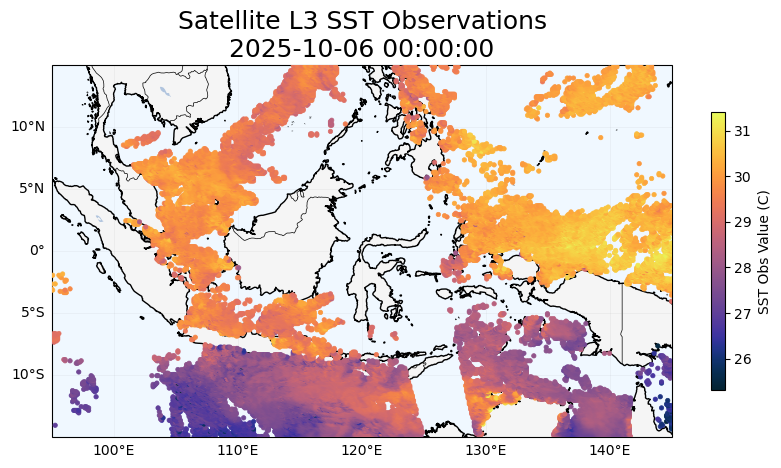


### Interpretation of Satellite SST Observations

Satellite SST observations provide estimates of sea surface temperature over large spatial areas. 
Unlike in-situ observations, satellite measurements offer broad coverage but may contain spatially varying uncertainties. 
The colors in the figure above represent the observed sea surface temperature values.


In [9]:
# Extract data from the obs_seq file
df   = obs.df.copy()

data = df['observation'] 
lon  = df['longitude']
lat  = df['latitude']
err  = np.sqrt(df['obs_err_var'])
time = sorted(df['time'].unique())[0]

proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(10, 6))
ax  = plt.axes(projection=proj)

ax.set_facecolor('aliceblue') 
ax.add_feature(cfeature.LAND, facecolor='whitesmoke', zorder=1) 
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'coastline', '10m'), 
               edgecolor='black', facecolor='none', zorder=2)
ax.add_feature(cfeature.LAKES, facecolor='lightsteelblue', zorder=2)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, zorder=2)


# Observations
sc = ax.scatter(lon, lat,
                c=data, s = 10,
                cmap=cmocean.cm.thermal, linewidth=0.5,
                zorder=3,
                transform=proj)

cb = plt.colorbar(sc, ax=ax, label='SST Obs Value (C)', shrink=0.6)

ax.set_extent([95, 145, -15, 15], crs=proj)

gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.1)
gl.top_labels   = False
gl.right_labels = False

plt.title(f"Satellite L3 SST Observations\n{time}", fontsize=18)
plt.show()

display(Markdown("""
### Interpretation of Satellite SST Observations

Satellite SST observations provide estimates of sea surface temperature over large spatial areas. 
Unlike in-situ observations, satellite measurements offer broad coverage but may contain spatially varying uncertainties. 
The colors in the figure above represent the observed sea surface temperature values.
"""))

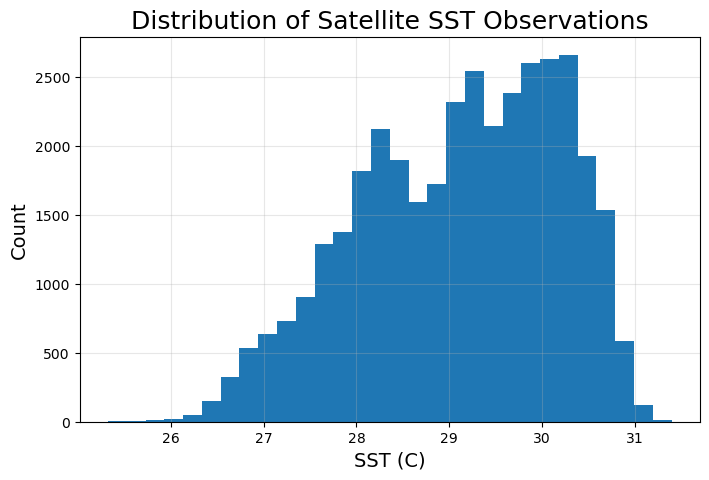

In [71]:
# Histogram 
plt.figure(figsize=(8,5))

plt.hist(data, bins=30)

plt.xlabel("SST (C)", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.title("Distribution of Satellite SST Observations", fontsize=18)
plt.grid(alpha=0.3)

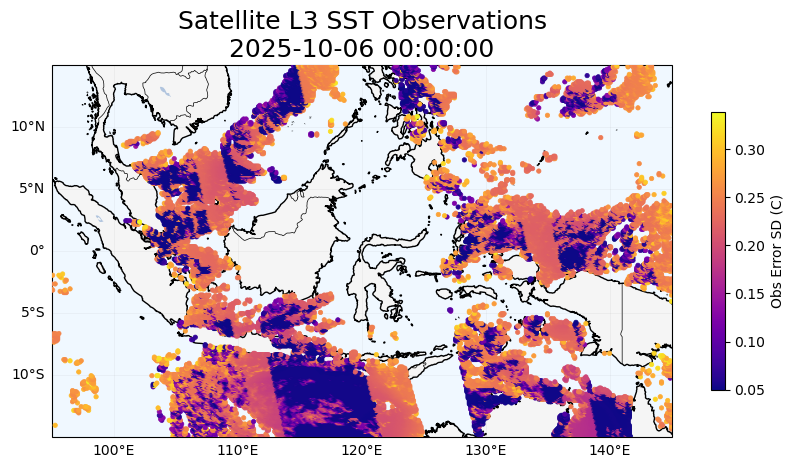


### Interpretation of SST Observation Errors

The colors in the figure above represent the observation error standard deviation assigned to each satellite SST observation. 
Smaller values indicate observations that are expected to be more accurate and therefore receive greater weight during data assimilation. 
The spatial variability in the assigned errors originates from the uncertainty estimates provided with the SST product. 
Regions with lower uncertainties (dark colors) generally correspond to areas where the satellite retrievals are considered more reliable, while regions with higher uncertainties (bright colors) indicate reduced confidence in the observations.
These uncertainties are carried into the DART observation sequence file and are used during assimilation to determine how strongly each observation influences the model analysis.


In [12]:
# Display the errors
fig = plt.figure(figsize=(10, 6))
ax  = plt.axes(projection=proj)

ax.set_facecolor('aliceblue') 
ax.add_feature(cfeature.LAND, facecolor='whitesmoke', zorder=1) 
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'coastline', '10m'), 
               edgecolor='black', facecolor='none', zorder=2)
ax.add_feature(cfeature.LAKES, facecolor='lightsteelblue', zorder=2)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, zorder=2)


# Observations
sc = ax.scatter(lon, lat,
                c=err, s = 10,
                cmap='plasma', linewidth=0.5,
                zorder=3,
                transform=proj)

cb = plt.colorbar(sc, ax=ax, label='Obs Error SD (C)', shrink=0.6)

ax.set_extent([95, 145, -15, 15], crs=proj)

gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.1)
gl.top_labels   = False
gl.right_labels = False

plt.title(f"Satellite L3 SST Observations\n{time}", fontsize=18)
plt.show()

display(Markdown("""
### Interpretation of SST Observation Errors

The colors in the figure above represent the observation error standard deviation assigned to each satellite SST observation. 
Smaller values indicate observations that are expected to be more accurate and therefore receive greater weight during data assimilation. 
The spatial variability in the assigned errors originates from the uncertainty estimates provided with the SST product. 
Regions with lower uncertainties (dark colors) generally correspond to areas where the satellite retrievals are considered more reliable, while regions with higher uncertainties (bright colors) indicate reduced confidence in the observations.
These uncertainties are carried into the DART observation sequence file and are used during assimilation to determine how strongly each observation influences the model analysis.
"""))

## 6. Observation Statistics

In [13]:
print(f"Longitude range : {df['longitude'].min():.2f}° to {df['longitude'].max():.2f}°")
print(f"Latitude range  : {df['latitude'].min():.2f}° to {df['latitude'].max():.2f}°")
print(f"Time range      : {df['time'].min()} to {df['time'].max()}\n")

summary = pd.DataFrame({
    "Count"        : [len(df)],
    "Min SST"      : [df["observation"].min()],
    "Max SST"      : [df["observation"].max()],
    "Mean SST"     : [df["observation"].mean()],
    "Std SST"      : [df["observation"].std()],
    "Mean Error"   : [np.sqrt(df["obs_err_var"]).mean()],
})

display(summary.round(3).style.hide(axis="index"))

Longitude range : 90.05° to 144.95°
Latitude range  : -14.95° to 14.95°
Time range      : 2025-10-06 00:00:00 to 2025-10-06 00:00:00



Count,Min SST,Max SST,Mean SST,Std SST,Mean Error
36638,25.320000,31.400000,29.110000,1.079000,0.161000


## Key Takeaways

- Satellite SST observations provide broad spatial coverage of sea surface temperature.
- The converter creates SATELLITE_BLENDED_SST observations in DART obs_seq format.
- Observation errors are derived from the uncertainty information provided with the SST product.
- SST observations are often among the most spatially extensive observations assimilated into ocean models.
- pyDARTdiags can be used to inspect and visualize the resulting obs_seq files.